Decision Tree Classifier (DTR) Implementation


Decision Tree Classifier (DTR) - a very interpretable and versatile model. 
We will use the Titanic dataset which is excellent for learning classification with mixed data types.



1 Load and Explore the Dataset

In [26]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, export_graphviz
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           roc_curve, auc, precision_recall_curve)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Decision Tree Classifier with Titanic Dataset")
print("=" * 60)

# Load Titanic dataset from seaborn
print("\n1. Loading Titanic dataset...")
try:
    # Try loading from seaborn first
    titanic_df = sns.load_dataset('titanic')
    print("Dataset loaded successfully from seaborn!")
except:
    # Fallback: Load from URL
    print("Loading from alternative source...")
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    titanic_df = pd.read_csv(url)
    print("Dataset loaded successfully from URL!")

print(f"Dataset shape: {titanic_df.shape}")
print(f"\nColumns: {list(titanic_df.columns)}")

Decision Tree Classifier with Titanic Dataset

1. Loading Titanic dataset...
Dataset loaded successfully from seaborn!
Dataset shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


2 Data Inspection and Cleaning

In [27]:
print("\n2. Data Inspection and Cleaning")
print("-" * 40)

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(titanic_df.head())

# Dataset information
print("\nDataset Info:")
print(titanic_df.info())

# Check for missing values
print("\nMissing values in each column:")
missing_data = titanic_df.isnull().sum()
missing_percentage = (missing_data / len(titanic_df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percentage
})
print(missing_df[missing_df['Missing Values'] > 0])

# Statistical summary
print("\nStatistical Summary:")
print(titanic_df.describe(include='all'))

# Check class distribution (survived vs not survived)
print("\nSurvival Distribution:")
survival_counts = titanic_df['survived'].value_counts()
survival_percent = titanic_df['survived'].value_counts(normalize=True) * 100
print(pd.DataFrame({
    'Count': survival_counts,
    'Percentage': survival_percent
}))


2. Data Inspection and Cleaning
----------------------------------------

First 5 rows of the dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 colum






3 Data Visualization


3. Data Visualization
----------------------------------------


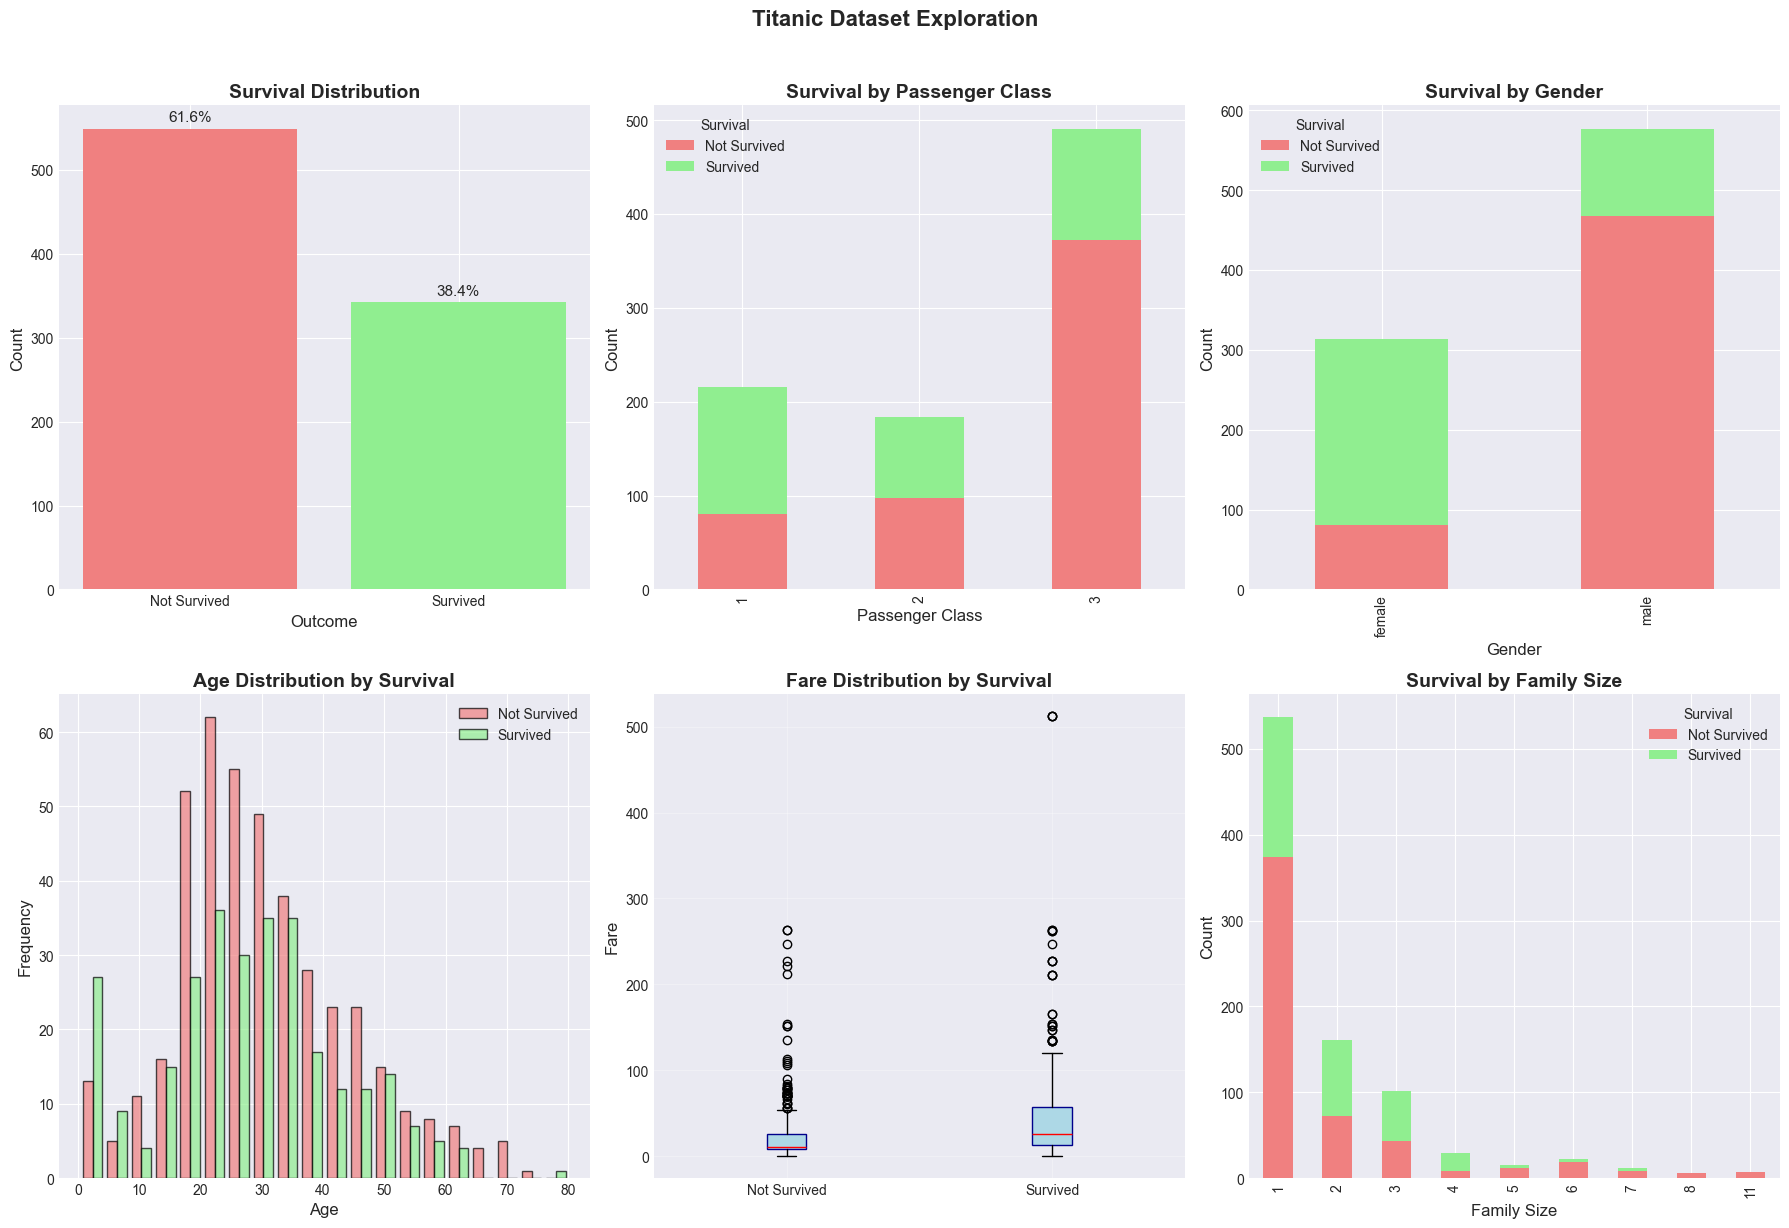

In [28]:
print("\n3. Data Visualization")
print("-" * 40)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Titanic Dataset Exploration', fontsize=16, fontweight='bold', y=1.02)

# 1. Survival distribution
ax1 = axes[0, 0]
colors = ['lightcoral', 'lightgreen']
bars = ax1.bar(['Not Survived', 'Survived'], survival_counts.values, color=colors)
ax1.set_title('Survival Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xlabel('Outcome', fontsize=12)

# Add percentage labels on bars
for bar, percent in zip(bars, survival_percent.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 5, 
             f'{percent:.1f}%', ha='center', va='bottom', fontsize=11)

# 2. Survival by class
ax2 = axes[0, 1]
class_survival = titanic_df.groupby(['pclass', 'survived']).size().unstack()
class_survival.plot(kind='bar', stacked=True, color=['lightcoral', 'lightgreen'], ax=ax2)
ax2.set_title('Survival by Passenger Class', fontsize=14, fontweight='bold')
ax2.set_xlabel('Passenger Class', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.legend(['Not Survived', 'Survived'], title='Survival')

# 3. Survival by gender
ax3 = axes[0, 2]
gender_survival = titanic_df.groupby(['sex', 'survived']).size().unstack()
gender_survival.plot(kind='bar', stacked=True, color=['lightcoral', 'lightgreen'], ax=ax3)
ax3.set_title('Survival by Gender', fontsize=14, fontweight='bold')
ax3.set_xlabel('Gender', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.legend(['Not Survived', 'Survived'], title='Survival')

# 4. Age distribution by survival
ax4 = axes[1, 0]
survived_age = titanic_df[titanic_df['survived'] == 1]['age'].dropna()
not_survived_age = titanic_df[titanic_df['survived'] == 0]['age'].dropna()

ax4.hist([not_survived_age, survived_age], bins=20, color=['lightcoral', 'lightgreen'], 
         label=['Not Survived', 'Survived'], alpha=0.7, edgecolor='black')
ax4.set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
ax4.set_xlabel('Age', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.legend()

# 5. Fare distribution by survival
ax5 = axes[1, 1]
survived_fare = titanic_df[titanic_df['survived'] == 1]['fare'].dropna()
not_survived_fare = titanic_df[titanic_df['survived'] == 0]['fare'].dropna()

ax5.boxplot([not_survived_fare, survived_fare], labels=['Not Survived', 'Survived'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'))
ax5.set_title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
ax5.set_ylabel('Fare', fontsize=12)
ax5.grid(True, alpha=0.3)

# 6. Family size vs survival
ax6 = axes[1, 2]
titanic_df['family_size'] = titanic_df['sibsp'] + titanic_df['parch'] + 1
family_survival = titanic_df.groupby(['family_size', 'survived']).size().unstack().fillna(0)
family_survival.plot(kind='bar', stacked=True, color=['lightcoral', 'lightgreen'], ax=ax6)
ax6.set_title('Survival by Family Size', fontsize=14, fontweight='bold')
ax6.set_xlabel('Family Size', fontsize=12)
ax6.set_ylabel('Count', fontsize=12)
ax6.legend(['Not Survived', 'Survived'], title='Survival')

plt.tight_layout()
plt.show()




4 Feature Engineering and Preprocessing


In [18]:
# ============================================================================
# 4. Feature Engineering and Preprocessing - FIXED VERSION
# ============================================================================

print("\n4. Feature Engineering and Preprocessing")
print("-" * 40)

# Create a copy for preprocessing
df = titanic_df.copy()

print(f"Available columns: {list(df.columns)}")

# Handle missing values
print("\nHandling missing values...")

# Check which columns exist and have missing values
print("Checking for missing values...")
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}")

# Handle missing values for columns that exist
if 'age' in df.columns:
    print("Processing age column...")
    # Age: Fill with median grouped by passenger class and gender
    df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(lambda x: x.fillna(x.median()))
    # Fill any remaining NaNs with overall median
    df['age'] = df['age'].fillna(df['age'].median())

if 'embarked' in df.columns:
    print("Processing embarked column...")
    # Embarked: Fill with mode
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Cabin: Only process if it exists
if 'cabin' in df.columns:
    print("Processing cabin column...")
    df['deck'] = df['cabin'].str[0]  # Extract first letter (deck)
    df['deck'] = df['deck'].fillna('Unknown')
else:
    print("Cabin column not found, skipping deck extraction...")
    df['deck'] = 'Unknown'

# Create new features
print("\nCreating new features...")

# 1. Title from name (if name column exists)
if 'name' in df.columns:
    print("Extracting title from name...")
    df['title'] = df['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    
    # Group rare titles
    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
        'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
        'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
        'Capt': 'Rare', 'Sir': 'Rare'
    }
    df['title'] = df['title'].map(title_mapping)
    df['title'] = df['title'].fillna('Rare')  # Fill any unmapped titles
else:
    print("Name column not found, skipping title extraction...")
    df['title'] = 'Unknown'

# 2. Family size (check if sibsp and parch exist)
if 'sibsp' in df.columns and 'parch' in df.columns:
    print("Calculating family size...")
    df['family_size'] = df['sibsp'] + df['parch'] + 1
else:
    print("sibsp or parch columns not found, setting family_size to 1...")
    df['family_size'] = 1

# 3. Is alone
df['is_alone'] = (df['family_size'] == 1).astype(int)

# 4. Age groups (if age exists)
if 'age' in df.columns:
    print("Creating age groups...")
    df['age_group'] = pd.cut(df['age'], 
                            bins=[0, 12, 18, 35, 50, 65, 100],
                            labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Middle Aged', 'Senior'])
else:
    df['age_group'] = 'Adult'

# 5. Fare per person (if fare exists)
if 'fare' in df.columns:
    print("Calculating fare per person...")
    df['fare_per_person'] = df['fare'] / df['family_size']
    # Handle division by zero or NaN
    df['fare_per_person'] = df['fare_per_person'].replace([np.inf, -np.inf], np.nan)
    df['fare_per_person'] = df['fare_per_person'].fillna(df['fare'])
else:
    df['fare_per_person'] = 0

print("\nChecking which features are available for modeling...")

# List of all possible features
all_possible_features = [
    'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
    'embarked', 'title', 'family_size', 'is_alone', 'fare_per_person', 'deck'
]

# Only use features that actually exist in our dataframe
features_to_use = [col for col in all_possible_features if col in df.columns]

print(f"\nFeatures available for modeling: {features_to_use}")
print(f"Total features: {len(features_to_use)}")

# Prepare feature matrix
X = df[features_to_use].copy()
y = df['survived']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Display sample of features
print("\nSample of feature matrix (first 3 rows):")
print(X.head(3))

# Encode categorical variables
print("\nEncoding categorical variables...")
label_encoders = {}

categorical_columns = ['sex', 'embarked', 'title', 'age_group', 'deck']

for column in categorical_columns:
    if column in X.columns:
        try:
            le = LabelEncoder()
            X[column] = le.fit_transform(X[column].astype(str))
            label_encoders[column] = le
            print(f"✓ Encoded {column}")
        except Exception as e:
            print(f"✗ Could not encode {column}: {e}")
            # Remove the column if encoding fails
            if column in X.columns:
                X = X.drop(columns=[column])
                print(f"  Removed {column} from features")

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Features after encoding: {list(X.columns)}")
print(f"Number of label encoders created: {len(label_encoders)}")

# Check for any remaining NaN values
print(f"\nRemaining NaN values in features: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    print("Filling remaining NaN values with median for numerical columns...")
    for column in X.columns:
        if X[column].dtype in ['float64', 'int64']:
            X[column] = X[column].fillna(X[column].median())
        else:
            X[column] = X[column].fillna(0)
    
print("✓ All NaN values handled!")


4. Feature Engineering and Preprocessing
----------------------------------------
Available columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'family_size']

Handling missing values...
Checking for missing values...
Columns with missing values: ['age', 'embarked', 'deck', 'embark_town']
Processing age column...
Processing embarked column...
Cabin column not found, skipping deck extraction...

Creating new features...
Name column not found, skipping title extraction...
Calculating family size...
Creating age groups...
Calculating fare per person...

Checking which features are available for modeling...

Features available for modeling: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'title', 'family_size', 'is_alone', 'fare_per_person', 'deck']
Total features: 12

Feature matrix shape: (891, 12)
Target vector shape: (891,)

Sample of feature matrix (first 3 rows):
   






5 Train-Test Split and Scaling


In [19]:
print("\n5. Train-Test Split and Data Preparation")
print("-" * 40)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Testing class distribution: {np.bincount(y_test)}")

# Scale numerical features (optional for Decision Trees, but good practice)
scaler = StandardScaler()
numerical_cols = ['age', 'fare', 'sibsp', 'parch', 'family_size', 'fare_per_person']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nFeatures scaled successfully!")


5. Train-Test Split and Data Preparation
----------------------------------------
Training set size: (712, 12)
Testing set size: (179, 12)

Training class distribution: [439 273]
Testing class distribution: [110  69]

Features scaled successfully!






6 Train Basic Decision Tree


In [20]:
print("\n6. Training Basic Decision Tree Model")
print("-" * 40)

# Initialize and train basic decision tree
print("Training basic decision tree...")
dt_basic = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_basic.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = dt_basic.predict(X_train_scaled)
y_pred = dt_basic.predict(X_test_scaled)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Number of misclassified test samples: {(y_test != y_pred).sum()} out of {len(y_test)}")

# Feature importance
print("\nFeature Importance (Top 10):")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_basic.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))


6. Training Basic Decision Tree Model
----------------------------------------
Training basic decision tree...
Training Accuracy: 0.8287
Test Accuracy: 0.8045
Number of misclassified test samples: 35 out of 179

Feature Importance (Top 10):
            feature  importance
1               sex    0.609664
0            pclass    0.152018
10  fare_per_person    0.092050
2               age    0.086488
8       family_size    0.043114
3             sibsp    0.012810
5              fare    0.003856
4             parch    0.000000
7             title    0.000000
6          embarked    0.000000





7 Visualize the Decision Tree



7. Visualizing the Decision Tree
----------------------------------------


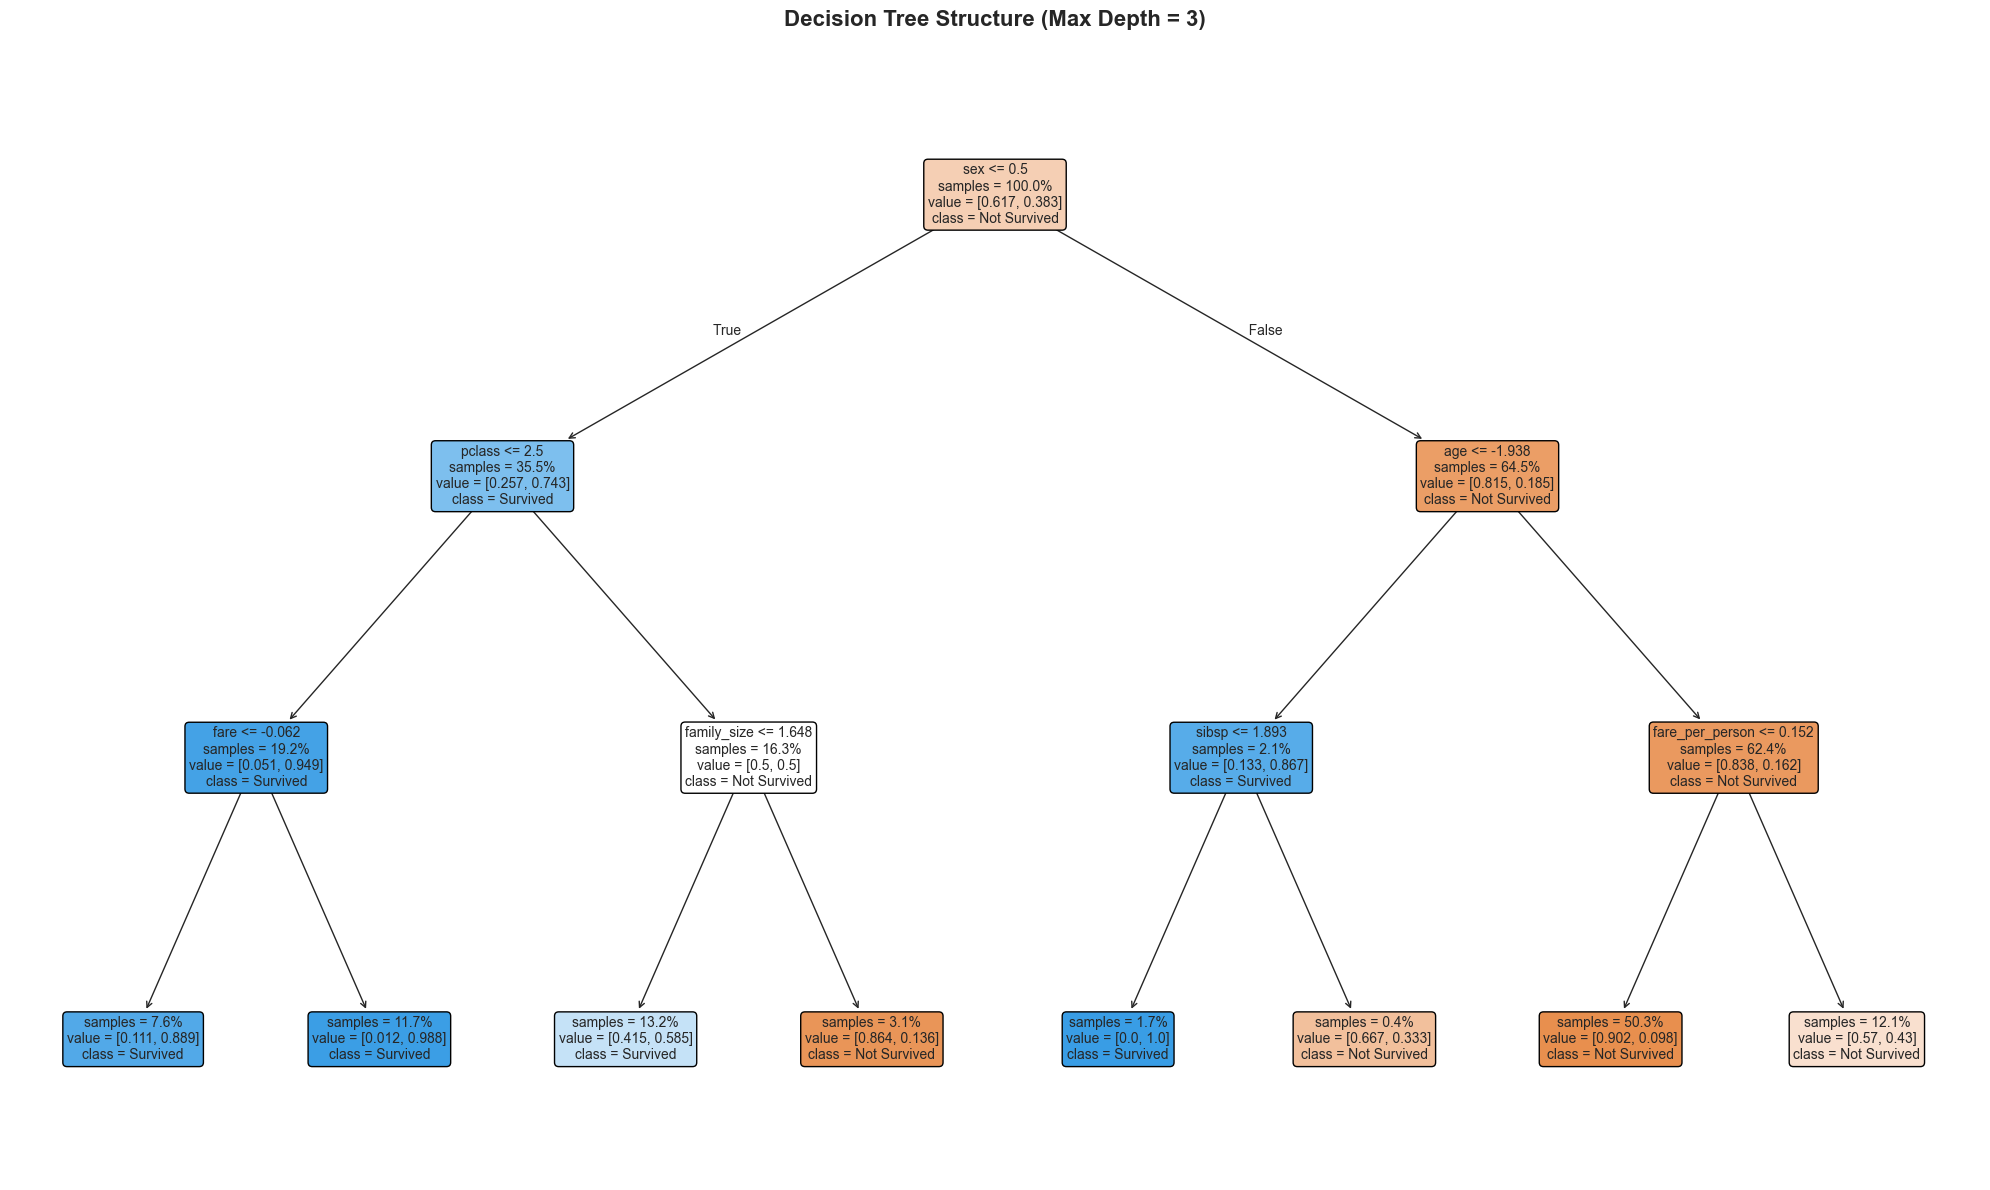


Text representation of the tree (first 3 levels):
|--- sex <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= -0.06
|   |   |   |--- class: 1
|   |   |--- fare >  -0.06
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- family_size <= 1.65
|   |   |   |--- class: 1
|   |   |--- family_size >  1.65
|   |   |   |--- class: 0
|--- sex >  0.50
|   |--- age <= -1.94
|   |   |--- sibsp <= 1.89
|   |   |   |--- class: 1
|   |   |--- sibsp >  1.89
|   |   |   |--- class: 0
|   |--- age >  -1.94
|   |   |--- fare_per_person <= 0.15
|   |   |   |--- class: 0
|   |   |--- fare_per_person >  0.15
|   |   |   |--- class: 0



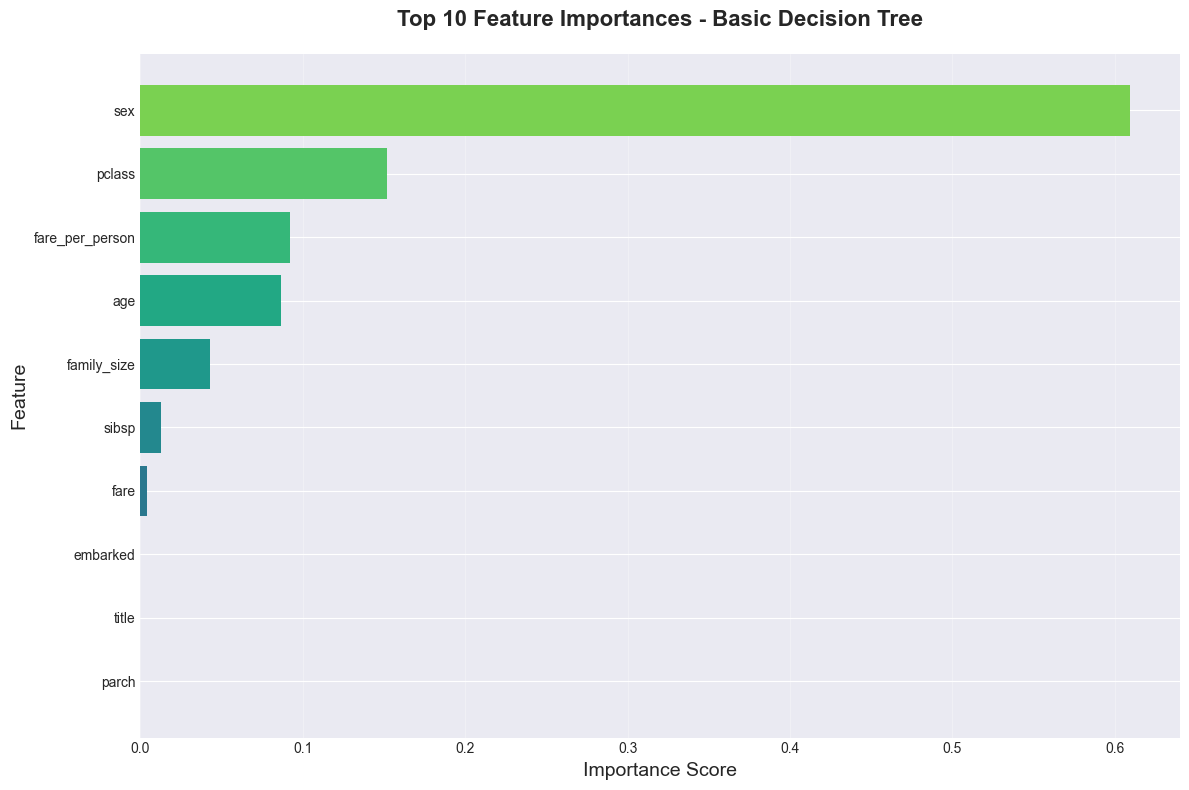

In [21]:
print("\n7. Visualizing the Decision Tree")
print("-" * 40)

# Visualize the tree structure
plt.figure(figsize=(20, 12))
plot_tree(dt_basic, 
          feature_names=X.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True,
          rounded=True,
          proportion=True,
          max_depth=3,  # Limit depth for visualization
          fontsize=10,
          impurity=False)

plt.title('Decision Tree Structure (Max Depth = 3)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()

# Text representation of the tree
print("\nText representation of the tree (first 3 levels):")
tree_rules = export_text(dt_basic, 
                         feature_names=list(X.columns),
                         max_depth=3,
                         decimals=2)
print(tree_rules)

# Feature importance visualization
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10).sort_values('importance', ascending=True)
plt.barh(range(len(top_features)), top_features['importance'], 
         color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features))))
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top 10 Feature Importances - Basic Decision Tree', 
          fontsize=16, fontweight='bold', pad=20)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



8 Hyperparameter Tuning with Grid Search


In [22]:
print("\n8. Hyperparameter Tuning with Grid Search")
print("-" * 40)

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

print("Performing Grid Search (this may take a minute)...")
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completed!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get best model
best_dt = grid_search.best_estimator_

# Evaluate best model
y_pred_best = best_dt.predict(X_test_scaled)
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Best model test accuracy: {best_accuracy:.4f}")

# Compare with basic model
print("\nModel Comparison:")
print(f"Basic Decision Tree Accuracy: {test_accuracy:.4f}")
print(f"Tuned Decision Tree Accuracy: {best_accuracy:.4f}")
print(f"Improvement: {(best_accuracy - test_accuracy) * 100:.2f}%")


8. Hyperparameter Tuning with Grid Search
----------------------------------------
Performing Grid Search (this may take a minute)...

Grid Search completed!
Best parameters: {'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best cross-validation accuracy: 0.8344
Best model test accuracy: 0.7765

Model Comparison:
Basic Decision Tree Accuracy: 0.8045
Tuned Decision Tree Accuracy: 0.7765
Improvement: -2.79%




9 Model Evaluation and Visualization



9. Model Evaluation and Visualization
----------------------------------------


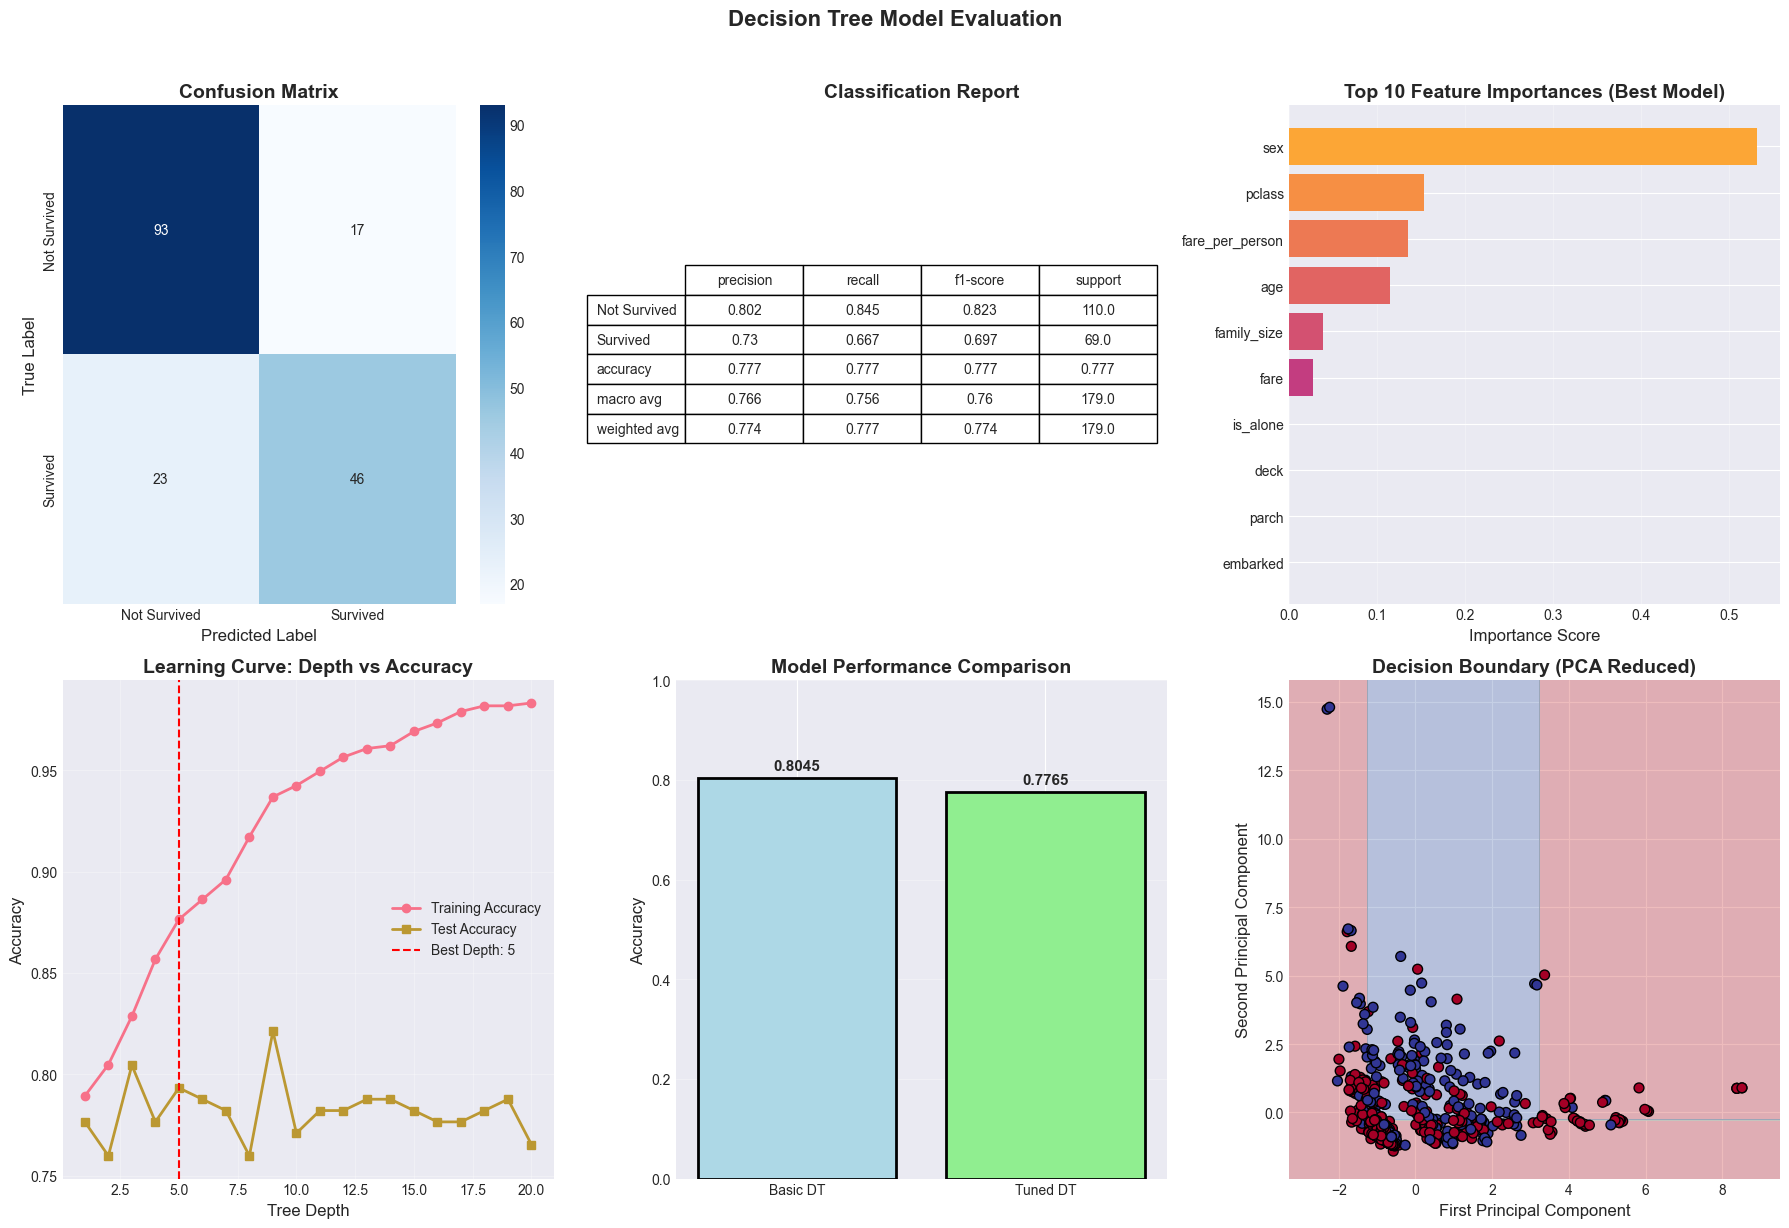

In [23]:
print("\n9. Model Evaluation and Visualization")
print("-" * 40)

# Create comprehensive evaluation
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Decision Tree Model Evaluation', fontsize=16, fontweight='bold', y=1.02)

# 1. Confusion Matrix
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_xlabel('Predicted Label', fontsize=12)

# 2. Classification Report
ax2 = axes[0, 1]
report = classification_report(y_test, y_pred_best, 
                              target_names=['Not Survived', 'Survived'],
                              output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)

# Create table
table = ax2.table(cellText=report_df.values,
                  rowLabels=report_df.index,
                  colLabels=report_df.columns,
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.2, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax2.set_title('Classification Report', fontsize=14, fontweight='bold')
ax2.axis('off')

# 3. Feature Importance (Best Model)
ax3 = axes[0, 2]
feature_importance_best = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

bars = ax3.barh(range(len(feature_importance_best)), 
                feature_importance_best['importance'],
                color=plt.cm.plasma(np.linspace(0.2, 0.8, len(feature_importance_best))))
ax3.set_yticks(range(len(feature_importance_best)))
ax3.set_yticklabels(feature_importance_best['feature'])
ax3.set_xlabel('Importance Score', fontsize=12)
ax3.set_title('Top 10 Feature Importances (Best Model)', fontsize=14, fontweight='bold')
ax3.grid(True, axis='x', alpha=0.3)

# 4. Learning Curve (Depth vs Accuracy)
ax4 = axes[1, 0]
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    train_scores.append(dt_temp.score(X_train_scaled, y_train))
    test_scores.append(dt_temp.score(X_test_scaled, y_test))

ax4.plot(depths, train_scores, 'o-', label='Training Accuracy', linewidth=2)
ax4.plot(depths, test_scores, 's-', label='Test Accuracy', linewidth=2)
ax4.axvline(x=best_dt.get_depth(), color='red', linestyle='--', 
           label=f'Best Depth: {best_dt.get_depth()}')
ax4.set_xlabel('Tree Depth', fontsize=12)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Learning Curve: Depth vs Accuracy', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Model Comparison
ax5 = axes[1, 1]
models = ['Basic DT', 'Tuned DT']
accuracies = [test_accuracy, best_accuracy]
colors = ['lightblue', 'lightgreen']

bars = ax5.bar(models, accuracies, color=colors, edgecolor='black', linewidth=2)
ax5.set_ylim([0, 1])
ax5.set_ylabel('Accuracy', fontsize=12)
ax5.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax5.grid(True, axis='y', alpha=0.3)

# Add accuracy values on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Decision Boundary Visualization (2D PCA)
ax6 = axes[1, 2]
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Train decision tree on 2D data
dt_2d = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_2d.fit(X_pca, y_train)

# Create mesh grid
h = 0.02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict on mesh grid
Z = dt_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
ax6.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
scatter = ax6.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, 
                      cmap=plt.cm.RdYlBu, edgecolor='k', s=50)
ax6.set_xlabel('First Principal Component', fontsize=12)
ax6.set_ylabel('Second Principal Component', fontsize=12)
ax6.set_title('Decision Boundary (PCA Reduced)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('decision_tree_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()





10 Cross-Validation and Final Evaluation



10. Cross-Validation and Final Evaluation
----------------------------------------
Performing 10-fold cross-validation...
Cross-validation scores: [0.7361 0.8611 0.831  0.7183 0.8169 0.8592 0.8873 0.8451 0.7606 0.8592]
Mean CV accuracy: 0.8175
Standard deviation: 0.0556


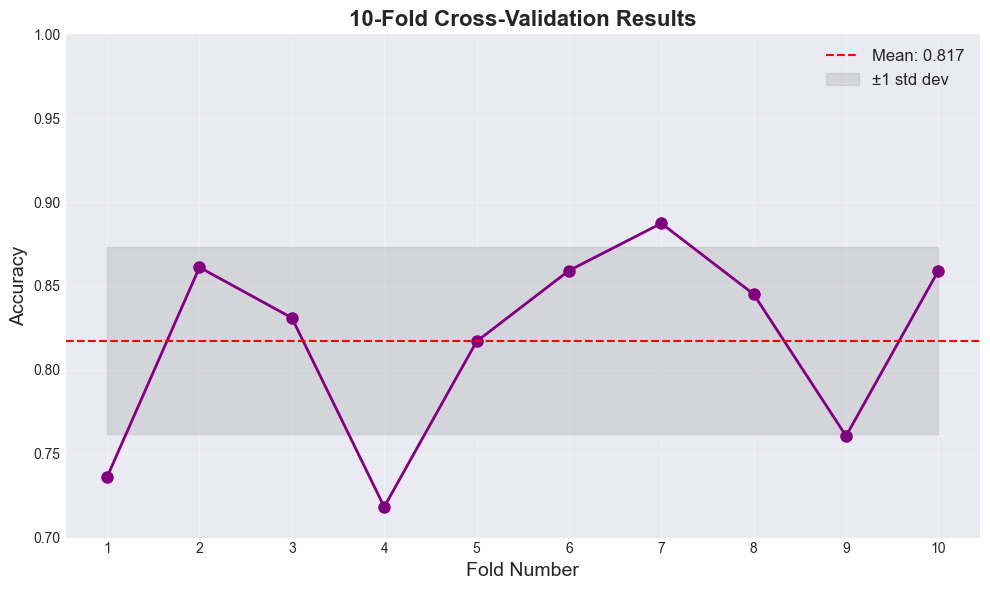


Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.85      0.82       110
    Survived       0.73      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.77       179


Detailed Metrics:
True Positives (TP): 46
True Negatives (TN): 93
False Positives (FP): 17
False Negatives (FN): 23

Sensitivity/Recall: 0.6667
Specificity: 0.8455
Precision: 0.7302
F1-Score: 0.6970


In [24]:
print("\n10. Cross-Validation and Final Evaluation")
print("-" * 40)

# Perform cross-validation
print("Performing 10-fold cross-validation...")
cv_scores = cross_val_score(best_dt, X_train_scaled, y_train, 
                           cv=10, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores.round(4)}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

# Plot CV results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores, 'o-', linewidth=2, markersize=8, color='purple')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', 
            label=f'Mean: {cv_scores.mean():.3f}')
plt.fill_between(range(1, 11), 
                 cv_scores.mean() - cv_scores.std(), 
                 cv_scores.mean() + cv_scores.std(), 
                 alpha=0.2, color='gray', label='±1 std dev')
plt.xlabel('Fold Number', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('10-Fold Cross-Validation Results', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

# Final detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best, 
                          target_names=['Not Survived', 'Survived']))

# Calculate additional metrics
TN, FP, FN, TP = cm.ravel()
print("\nDetailed Metrics:")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"\nSensitivity/Recall: {TP/(TP+FN):.4f}")
print(f"Specificity: {TN/(TN+FP):.4f}")
print(f"Precision: {TP/(TP+FP):.4f}")
print(f"F1-Score: {2*TP/(2*TP+FP+FN):.4f}")





11 Make Predictions on New Data




In [25]:
# ============================================================================
# 11. Making Predictions on New Data - FIXED VERSION
# ============================================================================

print("\n11. Making Predictions on New Data")
print("-" * 40)

# First, let's see what values were in the training data
print("Checking label encoders training classes...")
for column, encoder in label_encoders.items():
    print(f"{column} encoder classes: {encoder.classes_}")

# Create example passengers with values that match training data
print("\nCreating example passengers with known categories...")

# Get actual values from training data
sex_values = list(label_encoders.get('sex', LabelEncoder()).classes_) if 'sex' in label_encoders else ['male', 'female']
embarked_values = list(label_encoders.get('embarked', LabelEncoder()).classes_) if 'embarked' in label_encoders else ['C', 'Q', 'S']
title_values = list(label_encoders.get('title', LabelEncoder()).classes_) if 'title' in label_encoders else ['Mr', 'Mrs', 'Miss', 'Master', 'Rare']

print(f"Valid sex values: {sex_values}")
print(f"Valid embarked values: {embarked_values}")
print(f"Valid title values: {title_values}")

# Create example passengers with valid values
example_passengers = pd.DataFrame({
    'pclass': [1, 3, 2],
    'sex': ['female', 'male', 'female'] if 'female' in sex_values else [sex_values[0], sex_values[0], sex_values[0]],
    'age': [28, 22, 35],
    'sibsp': [0, 1, 0],
    'parch': [0, 0, 2],
    'fare': [500, 20, 80],
    'embarked': ['C', 'S', 'Q'] if all(x in embarked_values for x in ['C', 'S', 'Q']) else [embarked_values[0], embarked_values[0], embarked_values[0]],
    'title': ['Miss', 'Mr', 'Mrs'] if all(x in title_values for x in ['Miss', 'Mr', 'Mrs']) else [title_values[0], title_values[0], title_values[0]],
    'family_size': [1, 2, 3],
    'is_alone': [1, 0, 0],
    'fare_per_person': [500, 10, 26.67]
})

# Make sure we only use columns that exist in X
available_columns = [col for col in example_passengers.columns if col in X.columns]
example_passengers = example_passengers[available_columns]

print("\nExample passengers (using available features):")
print(example_passengers)

# Preprocess the new data
example_processed = example_passengers.copy()

# Encode categorical variables with error handling
print("\nEncoding categorical variables...")
for column in ['sex', 'embarked', 'title']:
    if column in example_processed.columns and column in label_encoders:
        try:
            # Check if all values are in the encoder's classes
            unique_vals = example_processed[column].unique()
            encoder_classes = set(label_encoders[column].classes_)
            
            # Replace any unknown values with the most common value
            for val in unique_vals:
                if val not in encoder_classes:
                    print(f"Warning: '{val}' not in {column} encoder classes. Replacing with most common value.")
                    most_common = label_encoders[column].classes_[0]  # Use first class as default
                    example_processed[column] = example_processed[column].replace(val, most_common)
            
            # Now transform
            example_processed[column] = label_encoders[column].transform(example_processed[column])
            print(f"✓ Successfully encoded {column}")
            
        except Exception as e:
            print(f"✗ Error encoding {column}: {e}")
            # If encoding fails, drop the column
            example_processed = example_processed.drop(columns=[column])
            print(f"  Dropped {column} from features")

# Scale numerical features (only those that exist in both)
print("\nScaling numerical features...")
available_numerical_cols = [col for col in numerical_cols if col in example_processed.columns]

if available_numerical_cols:
    try:
        example_processed[available_numerical_cols] = scaler.transform(example_processed[available_numerical_cols])
        print(f"✓ Successfully scaled {available_numerical_cols}")
    except Exception as e:
        print(f"✗ Error scaling features: {e}")
else:
    print("No numerical features to scale")

# Make sure all required columns are present (add missing ones with default values)
print("\nEnsuring all required features are present...")
for col in X.columns:
    if col not in example_processed.columns:
        print(f"  Adding missing column: {col} with default value 0")
        example_processed[col] = 0

# Reorder columns to match training data
example_processed = example_processed[X.columns]

print(f"\nFinal processed data shape: {example_processed.shape}")
print(f"Features: {list(example_processed.columns)}")

# Make predictions
try:
    predictions = best_dt.predict(example_processed)
    probabilities = best_dt.predict_proba(example_processed)
    
    print("\n" + "="*50)
    print("PREDICTIONS FOR EXAMPLE PASSENGERS")
    print("="*50)
    
    for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
        survival = "SURVIVED" if pred == 1 else "NOT SURVIVED"
        survival_prob = prob[1] if pred == 1 else prob[0]
        confidence_level = "HIGH" if survival_prob > 0.7 else "MEDIUM" if survival_prob > 0.5 else "LOW"
        
        print(f"\n🚢 Passenger {i+1}:")
        print(f"   Prediction: {survival}")
        print(f"   Confidence: {survival_prob:.3f} ({confidence_level})")
        print(f"   Probability Breakdown:")
        print(f"     - Not Survived: {prob[0]:.3f}")
        print(f"     - Survived: {prob[1]:.3f}")
        
        # Add some interpretation
        if pred == 1:
            if survival_prob > 0.8:
                print(f"   💡 Interpretation: Very likely to survive based on features")
            else:
                print(f"   💡 Interpretation: Moderately likely to survive")
        else:
            if survival_prob > 0.8:
                print(f"   💡 Interpretation: Very likely not to survive")
            else:
                print(f"   💡 Interpretation: Moderately likely not to survive")
                
except Exception as e:
    print(f"\n✗ Error making predictions: {e}")
    print("Troubleshooting steps:")
    print("1. Check if model is trained:", 'best_dt' in locals())
    print("2. Check feature alignment:")
    print(f"   - Example features: {list(example_processed.columns)}")
    print(f"   - Model expects: {list(X.columns) if 'X' in locals() else 'Unknown'}")
    
    # Try a simpler prediction if above fails
    print("\nTrying alternative prediction method...")
    try:
        # Use basic model instead
        if 'dt_basic' in locals():
            simple_predictions = dt_basic.predict(example_processed)
            print(f"Simple model predictions: {simple_predictions}")
    except:
        print("Could not make predictions with any model.")


11. Making Predictions on New Data
----------------------------------------
Checking label encoders training classes...
sex encoder classes: ['female' 'male']
embarked encoder classes: ['C' 'Q' 'S']
title encoder classes: ['Unknown']
deck encoder classes: ['Unknown']

Creating example passengers with known categories...
Valid sex values: ['female', 'male']
Valid embarked values: ['C', 'Q', 'S']
Valid title values: ['Unknown']

Example passengers (using available features):
   pclass     sex  age  sibsp  parch  fare embarked    title  family_size  \
0       1  female   28      0      0   500        C  Unknown            1   
1       3    male   22      1      0    20        S  Unknown            2   
2       2  female   35      0      2    80        Q  Unknown            3   

   is_alone  fare_per_person  
0         1           500.00  
1         0            10.00  
2         0            26.67  

Encoding categorical variables...
✓ Successfully encoded sex
✓ Successfully encoded emb